# ✈️ FareVision - Airfare Forecasting System
This notebook builds and tests machine learning models to predict flight prices based on features like airline, source, duration, stops, and more.

## 🔍 Objective
To predict the price of a flight using machine learning techniques on the `flight_data` dataset.


## 1. 📦 Importing Libraries
We begin by importing essential libraries for data manipulation, visualization, and modeling.


In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from scipy.stats import randint, uniform

## 2. 🗂️ Loading Data
We load the data and take an initial look.

In [3]:
data = pd.read_csv(r"C:\Users\ANURAG\Desktop\projects\airfare forecasting\flight_data.csv")

## 3. 📊 Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand its structure, uncover patterns, and identify any issues such as missing values, duplicates, or outliers.


### 📐 Shape and Structure of Data

This gives us an idea of dataset size and dimensionality.

In [4]:
#Shape of data

data_shape = data.shape
print(f'Shape of training data : {data_shape}')

Shape of training data : (40000, 12)


### 🧾 Column Names and Data Types

We inspect the column names and check data types to identify categorical vs. numerical features. This also helps in planning preprocessing and encoding steps.

* Numerical columns: price, duration, days_left
* Categorical columns: stops, class, departure, arrival, airline, source, destination, flight


In [5]:
#Information on data and column datatypes

data_info = data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    35208 non-null  object 
 5   stops        37681 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB


### 📊 Descriptive Statistics

Using `.describe()`, we look at mean, count, std, min, max, and percentiles of numerical features like `id`, `price`, `duration`, and `days_left`.

In [6]:
#Descriptive Statistics

data.describe()

,id,duration,days_left,price
count,40000.00000,36987.000000,35562.000000,40000.00000
mean,19999.50000,12.004088,26.197936,20801.49025
std,11547.14972,7.108063,13.469232,22729.14842
min,0.00000,0.830000,1.000000,1105.00000
25%,9999.75000,6.670000,15.000000,4687.00000
50%,19999.50000,11.080000,26.000000,7353.00000
75%,29999.25000,15.920000,38.000000,42521.00000
max,39999.00000,47.080000,49.000000,114704.00000


### ❗ Missing Values

We check for missing values using `.isnull().sum()`. Handling these is essential before modeling, especially for features like `days_left`.


In [7]:
missing_values = data.isnull().sum()
print(f'Number of missing values corresponding to each column :\n {missing_values}')

Number of missing values corresponding to each column :
 id                0
airline        4613
flight            0
source            0
departure      4792
stops          2319
arrival           0
destination       0
class             0
duration       3013
days_left      4438
price             0
dtype: int64


### 🔁 Duplicate Records

We find and count duplicate rows **excluding the `id` column**, which is unique by design.


In [8]:
number_of_duplicates = data.duplicated(subset=[col for col in data.columns if col != 'id']).sum()
print(f'Number of Duplicated Rows : {number_of_duplicates}')

Number of Duplicated Rows : 250


### 📦 Outlier Detection Using Boxplots

To visually identify potential outliers in the dataset, we plotted boxplots for all numeric columns.

💡 **Insights:**
* `id`: uniformly distributed, no predictive value — will be dropped.
* `duration`: shows several high-end outliers (possible long-haul flights).
* `days_left`: reasonable spread, no clear outliers.
* `price`: right-skewed with several high-priced outliers.


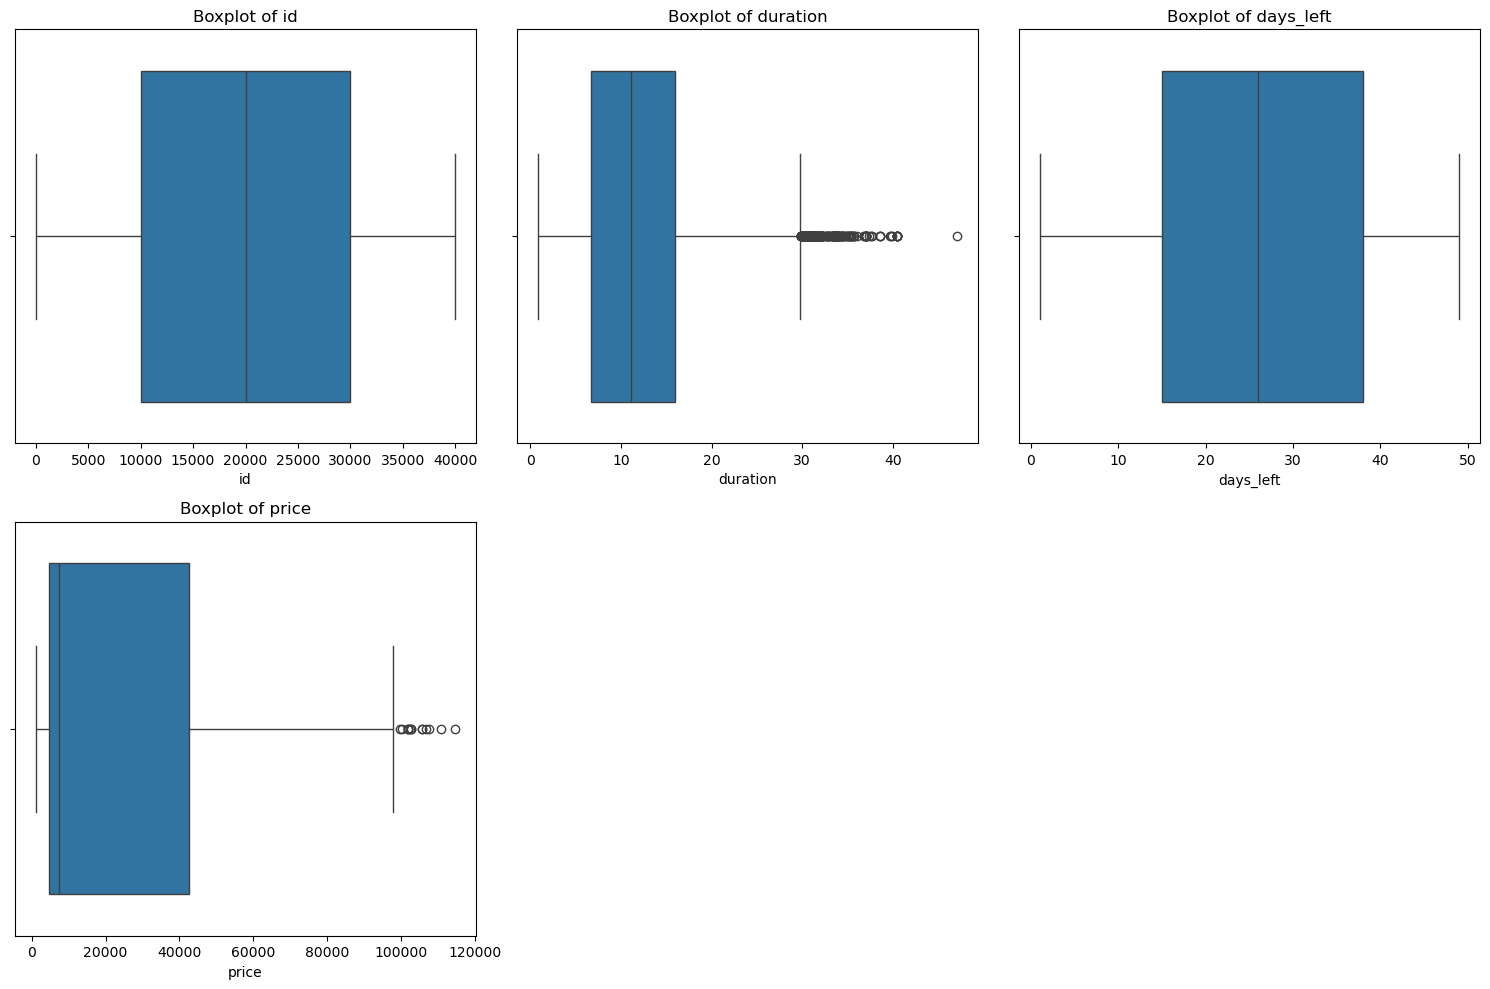

In [9]:
#Boxplot

numeric_cols = data.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols) // 3 + 1, 3, i)
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### 🌡️ Correlation Heatmap

We compute correlations between numerical features using `.corr()`.

💡 **Insights:**
* `duration` vs `price` → positive correlation, longer flights tend to be pricier.
* `days_left` vs `price` → negative correlation, booking earlier is usually cheaper.


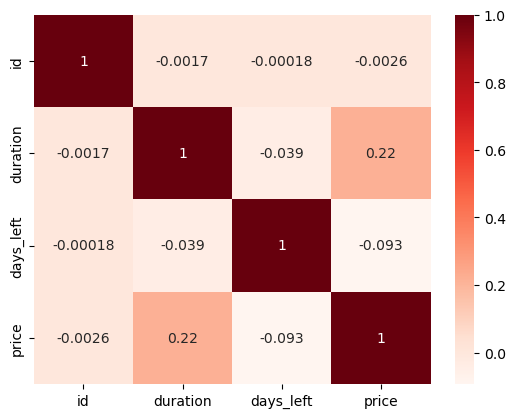

In [10]:
#Heatmap

numeric_cols = data.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, cmap='Reds', annot=True)
plt.show()

### 🧮 Target Distribution (Histogram)

We visualize the distribution of `price`, the target variable.

💡 **Insights**: The `price` distribution is right-skewed, so a log transform is applied before modeling.


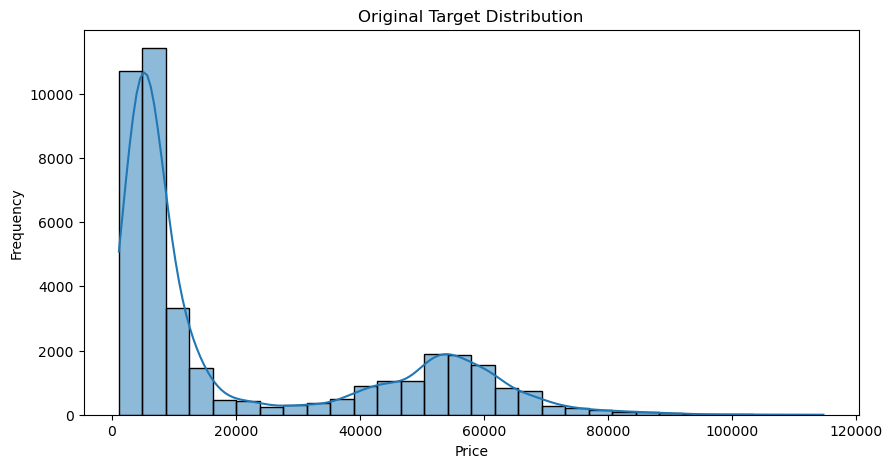

In [11]:
#Histogram

plt.figure(figsize=(10,5))
sns.histplot(data['price'], bins=30, kde=True)
plt.title("Original Target Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## 4. 🧹 Data Preprocessing

### ✅ Dropping Irrelevant Columns

The `id` column was dropped as it provides no predictive value.

In [12]:
#Dropping irrelevant columns

data = data.drop('id', axis=1)

### ✅ Adjusting flight Column

Some `flight` values were in scientific notation — these were replaced with NaN for consistency.

In [13]:
#Adjusting flight column (removing scientific notations)

data['flight'] = data['flight'].replace(to_replace=r'^\d+\.\d+[eE][+-]?\d+$', value=np.nan, regex=True)

### 📈 Outlier Handling

We capped outliers in `price` and `duration` using the IQR method to minimize distortion while preserving overall data distribution.

In [14]:
#Capping Outliers

def get_iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

def cap_column(series, lower, upper):
    return np.where(series < lower, lower,
                    np.where(series > upper, upper, series))

columns_with_outliers = ['price', 'duration']

for col in columns_with_outliers:
    lower, upper = get_iqr_bounds(data[col])
    data[col] = cap_column(data[col], lower, upper)

### 🎯 Feature & Target Separation

The target variable for this task is `price`. All other relevant columns were selected as features.

In [15]:
# Feature-Target Separation

X_train_data = data.drop('price', axis=1)
y_train_data = data['price']

### 🪓 Train-Validation-Test Split

The dataset was split into training, validation, and test sets to evaluate model generalization.

In [16]:
#Train-Test-Validation Split

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X_train_data, y_train_data, test_size=0.3, random_state=42)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### 🔢 Feature Engineering

The `flight` column has a large number of unique values, making it a high-cardinality categorical feature. Traditional one-hot encoding would create a very sparse, high-dimensional dataset. To address this, we applied **frequency encoding**, replacing each flight value with how often it appears in the dataset.

In [17]:
#Frequency Encoding

flight_freq = X_train['flight'].value_counts(normalize=True)

for df in [X_train, X_val, X_test]:
    df['flight_freq'] = df['flight'].map(flight_freq).fillna(0)
    df.drop('flight', axis=1, inplace=True)

### 🔄 Preprocessing Pipeline

We built customized preprocessing pipelines tailored to each feature type:

* **Airline**: `SimpleImputer(most_frequent)` + `OrdinalEncoder()`
* **Numerical columns** (duration, days_left, flight_freq): median imputation, with `StandardScaler()` in the scaled pipeline (needed for Linear Regression).
* **Ordinal columns** (stops, class, arrival, departure): `most_frequent` imputation + `OrdinalEncoder` with a domain-specific category order.
* **One-hot columns** (source, destination): `most_frequent` imputation + `OneHotEncoder(drop='first')`.

Everything is combined into a `ColumnTransformer`:
* `preprocessor_non_scaled` — for tree-based models (Random Forest, XGBoost)
* `preprocessor_scaled` — for scale-sensitive models (Linear Regression)


In [18]:
#Pipeline

num_missing_cols = ['duration', 'days_left', 'flight_freq']
one_hot_cols = ['source', 'destination']
ordinal_cols = ['stops', 'class', 'arrival', 'departure']
all_numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
ordinal_map = [
    ['zero', 'one', 'two_or_more'],
    ['Economy', 'Business'],
    ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night'],  # for 'departure'
    ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night']   # for 'arrival'
]

airline_pipeline = Pipeline([
    ('airline_imputer', SimpleImputer(strategy='most_frequent')),
    ('label_encoder', OrdinalEncoder())
])

num_pipeline = Pipeline([
    ('num_imputer', SimpleImputer(strategy='median'))
])

num_pipeline_scaled = Pipeline([
    ('num_imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline([
    ('ordinal_impute', SimpleImputer(strategy='most_frequent')),
    ('ordinal_encode', OrdinalEncoder(categories=ordinal_map))
])

one_hot_pipeline = Pipeline([
    ('one_hot_impute', SimpleImputer(strategy='most_frequent')),
    ('one_hot_encode', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor_non_scaled = ColumnTransformer([
    ('airline_label', airline_pipeline, ['airline']),
    ('numerical', num_pipeline, num_missing_cols),
    ('ordinal_encoding', ordinal_pipeline, ordinal_cols),
    ('one-hot-encoding', one_hot_pipeline, one_hot_cols)
], remainder='passthrough')

preprocessor_scaled = ColumnTransformer([
    ('airline_label', airline_pipeline, ['airline']),
    ('numerical', num_pipeline_scaled, all_numeric_cols),
    ('ordinal_encoding', ordinal_pipeline, ordinal_cols),
    ('one-hot-encoding', one_hot_pipeline, one_hot_cols)
], remainder='passthrough')

## 5. 🧠 Model Building, Tuning, and Evaluation

### 🏗️ Model Building

Only **3 regression models** were trained and compared for this project:
* Linear Regression
* Random Forest Regressor
* XGBoost Regressor

Each model was wrapped in a pipeline that included preprocessing specific to its requirements (scaled vs. non-scaled).


In [19]:
#Defining Models

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
}

### 🎯 Hyperparameter Tuning

**RandomizedSearchCV** was used to tune hyperparameters for the tree-based models:
* **Random Forest**: tuned `n_estimators` and `max_depth`
* **XGBoost**: tuned `n_estimators`, `max_depth`, `learning_rate`, `subsample`, and `colsample_bytree`


In [20]:
#Hyperparameter Tuning

param_distributions = {
    "Random Forest": {
        "model__n_estimators": randint(50, 200),
        "model__max_depth": randint(3, 20)
    },
    "XGBoost": {
        "model__n_estimators": randint(50, 200),
        "model__max_depth": randint(3, 20),
        "model__learning_rate": uniform(0.01, 0.3),
        "model__subsample": uniform(0.6, 0.4),
        "model__colsample_bytree": uniform(0.6, 0.4)
    }
}

# Only tune these models
models_to_tune = ["Random Forest", "XGBoost"]

for name in models_to_tune:
    print(f"Tuning {name}...")

    preprocessor = preprocessor_non_scaled

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', models[name])
    ])

    search = RandomizedSearchCV(
        pipeline,
        param_distributions[name],
        n_iter=10,
        cv=3,
        scoring='neg_root_mean_squared_error',
        verbose=0,
        random_state=42,
        n_jobs=1
    )

    search.fit(X_train, np.log1p(y_train))
    best_pipeline = search.best_estimator_

    # Update model with best model for use in evaluation
    models[name] = best_pipeline.named_steps['model']

Tuning Random Forest...
Tuning XGBoost...


Tuning XGBoost...


### 📊 Model Evaluation

All trained models were evaluated on the validation set using:
* **R² Score**
* **Root Mean Squared Error (RMSE)**
* **Mean Absolute Error (MAE)**

Predictions were log-transformed during training and inverse-transformed before evaluation. Results were compiled and sorted by **R² Score** for comparison.


In [21]:
#Training and Prediction on Evaluation set

results = []

tree_models = ['Random Forest', 'XGBoost']

for name, model in models.items():
    if name in tree_models:
        preprocessor = preprocessor_non_scaled
    else:
        preprocessor = preprocessor_scaled

    full_pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])

    full_pipeline.fit(X_train, np.log1p(y_train))
    preds_log = full_pipeline.predict(X_val)

    # Inverse log transform
    preds = np.expm1(preds_log)

    results.append({
        "Model": name,
        "R2 Score": r2_score(y_val, preds),
        "RMSE": np.sqrt(mean_squared_error(y_val, preds)),
        "MAE": mean_absolute_error(y_val, preds)
    })

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
display(results_df.reset_index(drop=True))

,Model,R2 Score,RMSE,MAE
0,XGBoost,0.979033,3285.731661,1769.005721
1,Random Forest,0.975711,3536.461172,1909.074036
2,Linear Regression,0.877377,7946.106891,4653.121727


### 📊 Model Comparison (Validation Set)

Three regression models were evaluated on the **validation set** using R² score to select the best-performing algorithm. This avoids data leakage and ensures a fair comparison.

#### 🏁 Compared Models:
Linear Regression, Random Forest, XGBoost


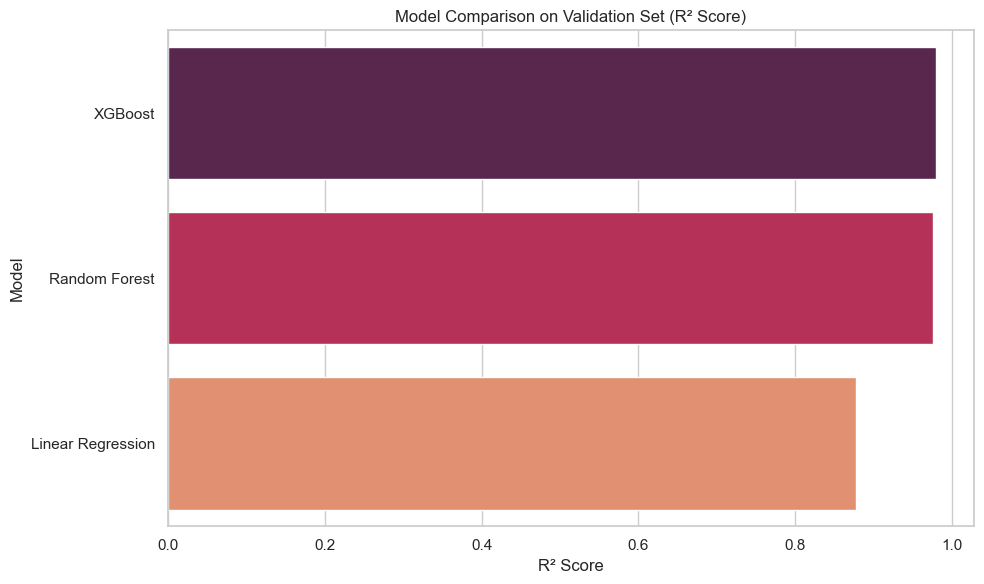

In [22]:
# Model Performance Analysis

sns.set(style="whitegrid")

# Sort by R² Score
performance_df = results_df.sort_values(by="R2 Score", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=performance_df, x="R2 Score", y="Model", palette="rocket")
plt.title("Model Comparison on Validation Set (R² Score)", fontsize=12)
plt.xlabel("R² Score")
plt.tight_layout()
plt.show()

### 🏁 Final Model Selection and Submission

* The **best-performing model** on the validation set was selected based on R² score.
* This model was retrained on the combined training and validation set (`X_full`, `y_full`).
* Final predictions were made on the test set.


In [23]:
# Combining train set and val set
X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

#Using best model for test prediction
final_results = []

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print("Best Model:", best_model_name)

if best_model_name == 'Linear Regression':
    final_pipeline = Pipeline([
        ('preprocess', preprocessor_scaled),
        ('model', best_model)
    ])
else:
    final_pipeline = Pipeline([
        ('preprocess', preprocessor_non_scaled),
        ('model', best_model)
    ])

final_pipeline.fit(X_full, np.log1p(y_full))
y_test_pred_log = final_pipeline.predict(X_test)
y_test_pred = np.expm1(y_test_pred_log)

final_results.append({
    "Model": best_model_name,
    "R2 Score": r2_score(y_test, y_test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
    "MAE": mean_absolute_error(y_test, y_test_pred)
})

final_results_df = pd.DataFrame(final_results)
display(final_results_df)

Best Model: XGBoost


,Model,R2 Score,RMSE,MAE
0,XGBoost,0.980998,3129.707358,1682.482221
